In [1]:
### Importing necessary libraries
import argparse

import EoN
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
import xgi

from src import *

set_fonts()

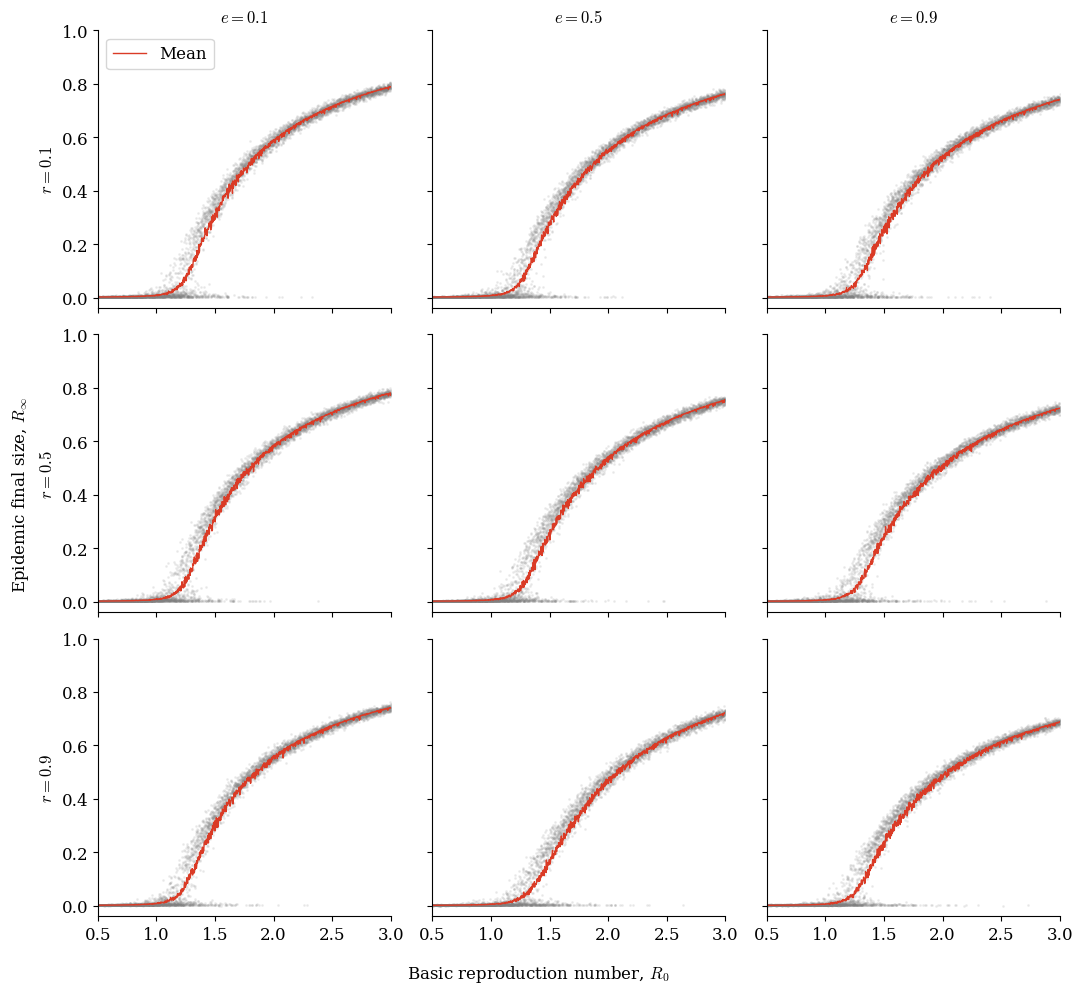

In [ ]:
vals = [0.1, 0.5, 0.9]

fig, ax = plt.subplots(figsize=(11, 10), nrows=3, ncols=3, sharex=True, sharey=True)
for i in range(3):
    for j in range(3):
        e = vals[i]
        r = vals[j]
        filepath = f"Data/Fig3_e_{e:.2f}_r_{r:.2f}_RandomData.csv"

        results_fig3 = pl.read_csv(filepath)
        results_mean = results_fig3.group_by("R0").agg(pl.mean("Rt")).sort("R0")

        ax[i, j].scatter(
            results_fig3["R0"][::20],
            results_fig3["Rt"][::20],
            alpha=0.1,
            color="grey",
            s=2 / 1.5,
        )
        ax[i, j].plot(
            results_mean["R0"],
            results_mean["Rt"],
            linewidth=1,
            color="#DA3B26",
            label="Mean",
        )

for i in range(3):
    ax[0, i].set_title(rf"$e = {vals[i]}$")
    ax[i, 0].set_ylabel(rf"$r = {vals[i]}$")

fig.supxlabel(r"Basic reproduction number, $R_0$")
fig.supylabel(r"Epidemic final size, $R_\infty$")

plt.xticks(np.linspace(0.5, 3.0, 6))
plt.yticks(np.linspace(0.0, 1.0, 6))

plt.xlim(0.5, 3.0)

ax[0, 0].legend(loc="upper left")

sns.despine()
plt.tight_layout()

plt.savefig("Figures/Figure-A1.png", dpi=1000)
plt.savefig("Figures/Figure-A1.svg", format="svg")
plt.savefig("Figures/Figure-A1.pdf", format="pdf")